In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
# Consistent visual style throughout the notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [3]:
# Load the dataset from a CSV file
path = 'research_centers.csv'
data = pd.read_csv(path)

data.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


## Exploratory Data Analysis (EDA)

### Data Quality Check

In [4]:
# Check the shape of the dataset
print(f'Dataset shape: {data.shape}')

Dataset shape: (50, 10)


In [5]:
# Check the data types of each column
print(f"Data types:\n{data.dtypes}")

Data types:
researchCenterId            object
researchCenterName          object
city                        object
latitude                   float64
longitude                  float64
internalFacilitiesCount      int64
hospitals_10km               int64
pharmacies_10km              int64
facilityDiversity_10km     float64
facilityDensity_10km       float64
dtype: object


In [6]:
# display summary statistics for numerical columns
print("Summary statistics for numerical columns:")
display(data.describe(include=[np.number]).T)

Summary statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
latitude,50.0,50.542770,0.320289,50.007100,50.240375,50.635350,50.831475,50.994600
longitude,50.0,-1.554638,0.253853,-1.976900,-1.747225,-1.561000,-1.374175,-1.049300
internalFacilitiesCount,50.0,5.660000,3.146816,1.000000,3.000000,5.000000,8.750000,11.000000
hospitals_10km,50.0,1.860000,1.340271,0.000000,1.000000,2.000000,3.000000,4.000000
pharmacies_10km,50.0,2.240000,1.684988,0.000000,1.000000,2.000000,3.000000,5.000000
facilityDiversity_10km,50.0,0.568843,0.249511,0.119515,0.344145,0.585503,0.800489,0.992984
facilityDensity_10km,50.0,0.321164,0.182562,0.056541,0.173814,0.297584,0.476387,0.697016


In [7]:
# Display categorical summary statistics
print("Summary statistics for categorical columns:")
display(data.describe(include=[object]).T)

Summary statistics for categorical columns:


,count,unique,top,freq
researchCenterId,50,50,RC-014,1
researchCenterName,50,50,Research Center 14,1
city,50,5,City 3,14


In [8]:
# Total number of research centers
total_centers = data['researchCenterId'].nunique()
print(f'Total number of research centers: {total_centers}')

Total number of research centers: 50


In [9]:
# Total number of cities
total_cities = data['city'].nunique()
print(f'Total number of cities: {total_cities}')

Total number of cities: 5


In [10]:
# Check for duplicate ids
duplicate_ids = data['researchCenterId'].duplicated().sum()
print(f'Number of duplicate ids: {duplicate_ids}')

Number of duplicate ids: 0


In [11]:
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64


### Data Distribution

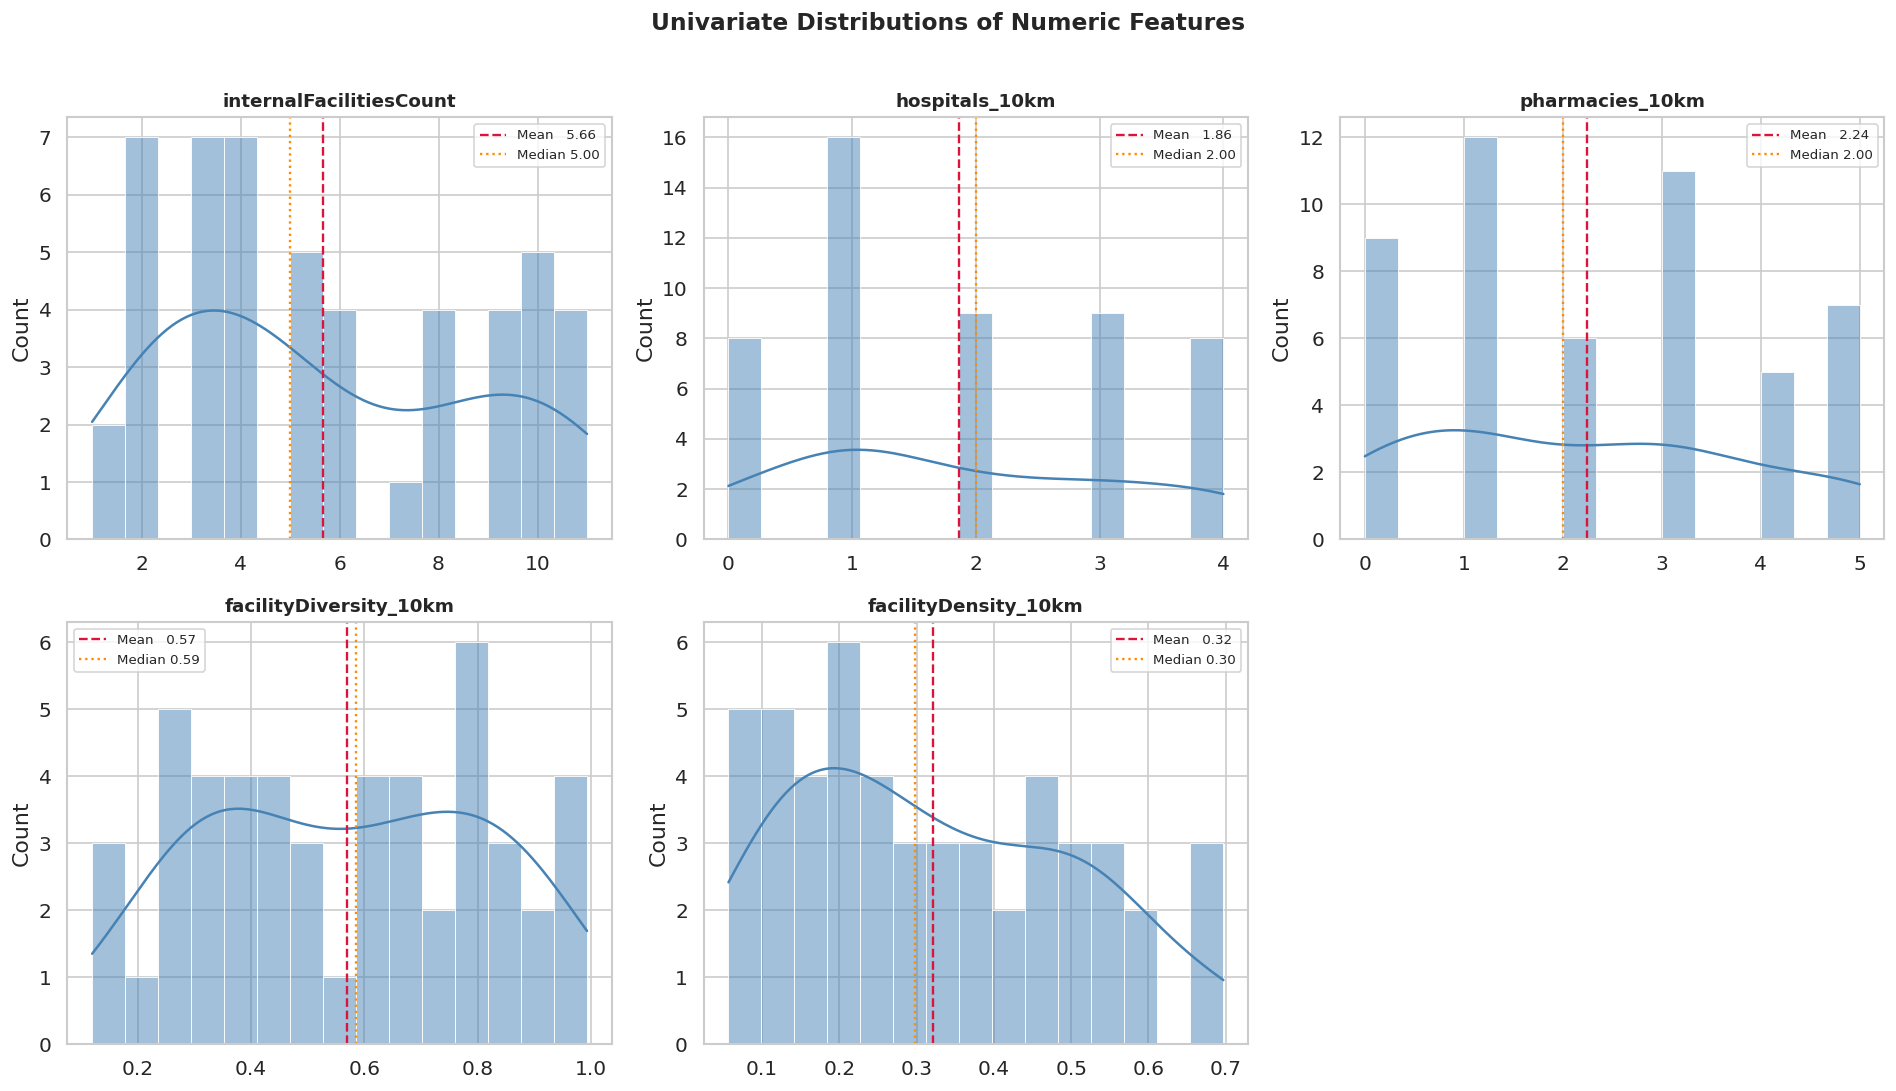

In [12]:
# --- Univariate Analysis of Numeric Features ---

numeric_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    sns.histplot(
        data[col],
        bins=15,
        kde=True,           # overlay kernel density estimate
        color="steelblue",
        ax=ax,
        edgecolor="white",
        linewidth=0.5,
    )
    # Mark the mean and median for quick visual comparison
    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color="crimson",      linestyle="--",
               linewidth=1.4, label=f"Mean   {mean_val:.2f}")
    ax.axvline(median_val, color="darkorange",   linestyle=":",
               linewidth=1.4, label=f"Median {median_val:.2f}")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle(
    "Univariate Distributions of Numeric Features",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("eda_univariate_distributions.png", bbox_inches="tight")
plt.show()

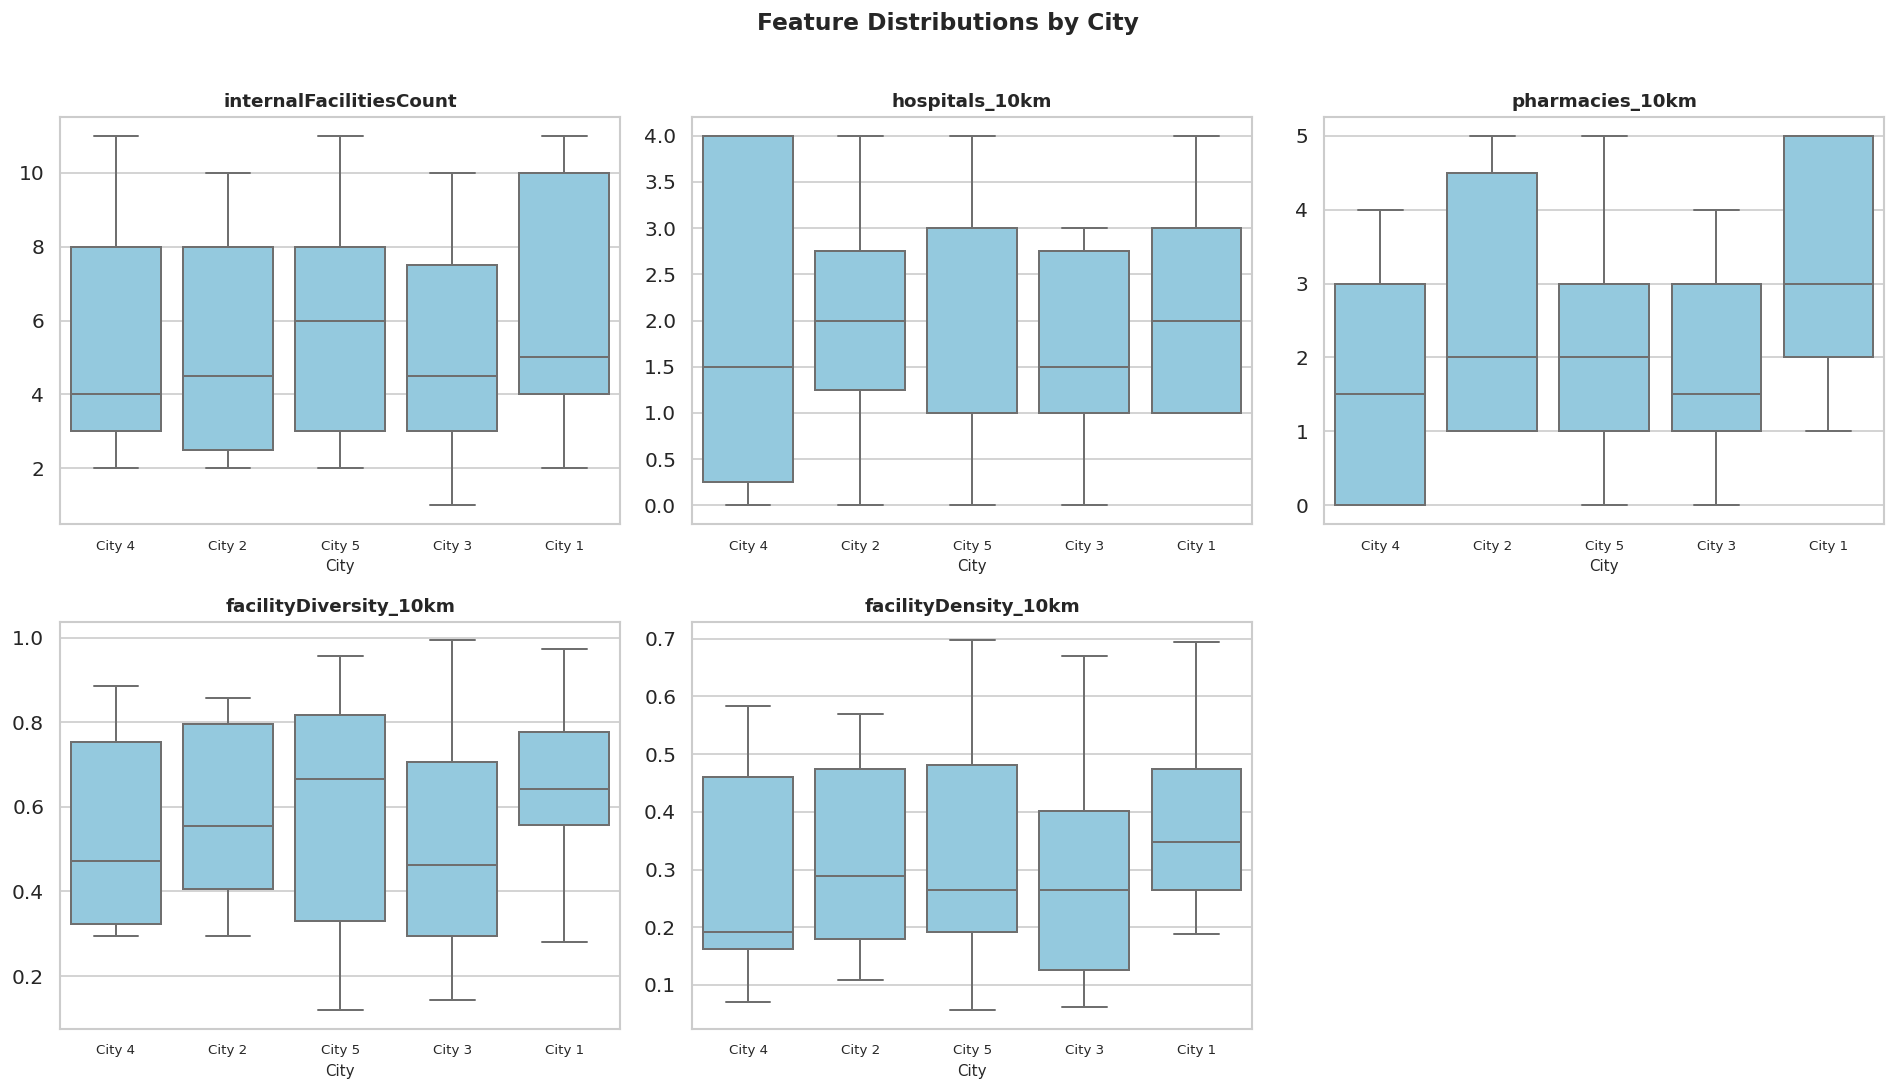

In [13]:
# --- Bivariate Analysis: Boxplots by City ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    sns.boxplot(
        data=data,
        x="city",
        y=col,
        color="skyblue",
        linewidth=1.2,
        flierprops=dict(marker="o", markerfacecolor="red",
                        markersize=4, alpha=0.6),
        ax=ax,
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("City", fontsize=9)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8)

axes[-1].set_visible(False)

fig.suptitle(
    "Feature Distributions by City",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("eda_boxplots_by_city.png", bbox_inches="tight")
plt.show()

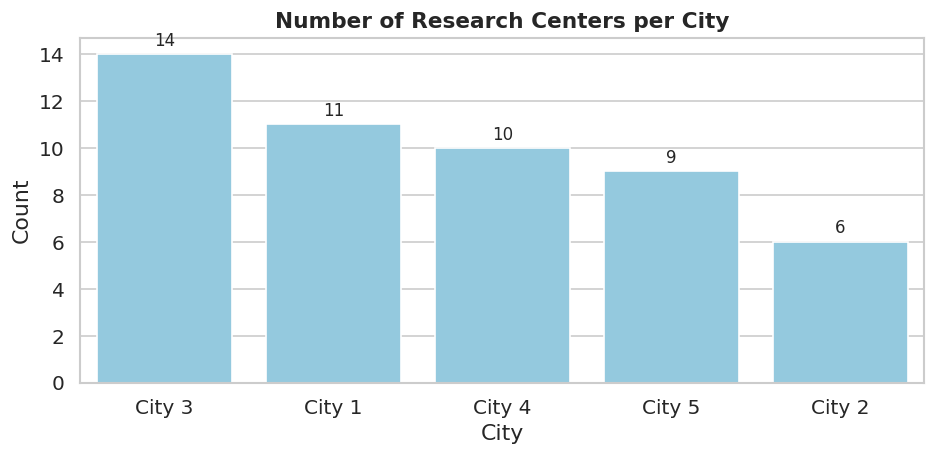

In [14]:
# --- Categorical Analysis: Count of Research Centers per City ---

city_counts = data["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]   # explicitly set column names

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=city_counts,
    x="city",
    y="count",
    color="skyblue",
    ax=ax,
    edgecolor="white",
)
ax.set_title("Number of Research Centers per City",
             fontsize=13, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Count")

# Annotate bars with exact counts
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.savefig("eda_centers_per_city.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

- City 3 has 2.3× more centers than City 2, the most imbalanced pair
- Cities 1, 4, and 5 are relatively balanced (9–11 centers each)
- No city has zero representation, all five contribute to the clustering
- Business implication: City 3 having the most centers but the lowest average internal facility count (5.07) suggests that quantity of centers does not equal quality, a finding only visible when combining this chart with the heatmap

### Correlations

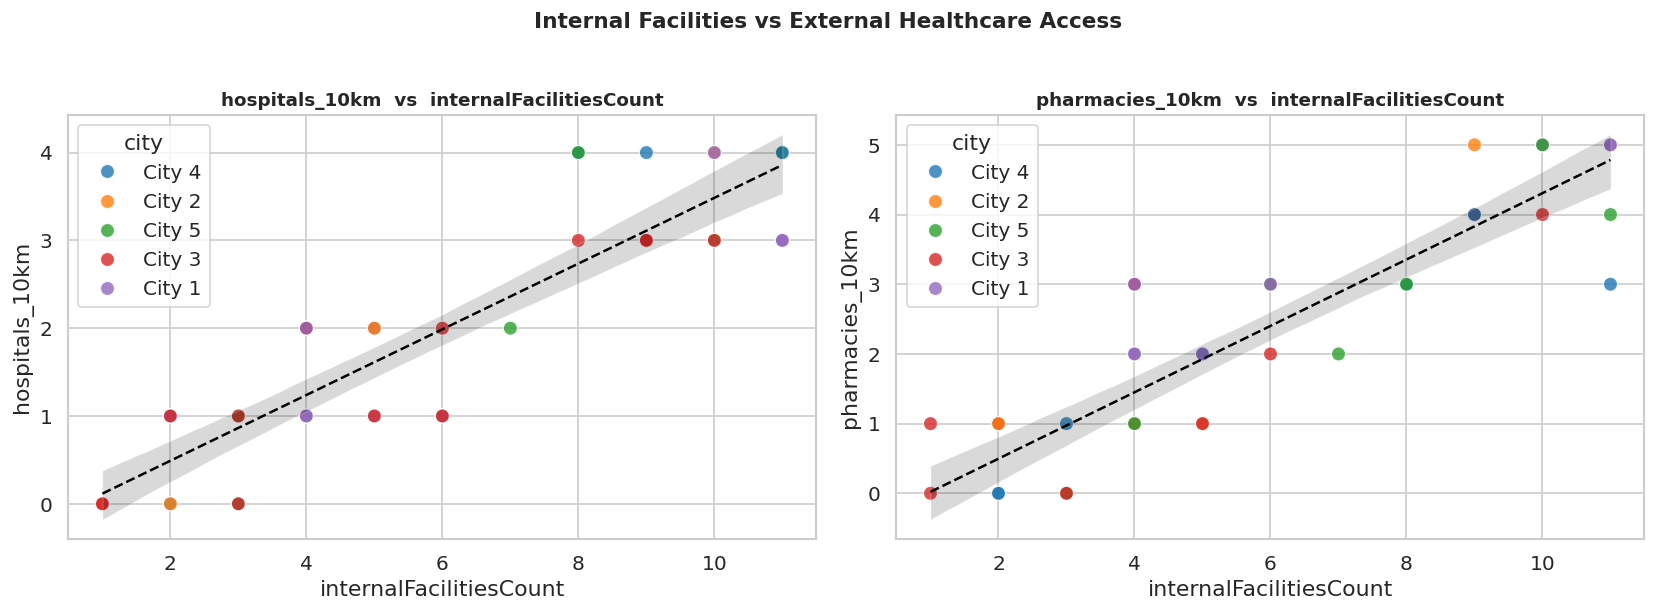

In [15]:
# --- Bivariate Analysis: Scatter Plots of Internal Facilities vs External Access (hospital & pharmacy access)---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_pairs = [
    ("internalFacilitiesCount", "hospitals_10km"),
    ("internalFacilitiesCount", "pharmacies_10km"),
]

for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        hue="city",
        palette="tab10",
        s=70,
        alpha=0.8,
        ax=ax,
    )
    # Regression trend line (no hue) to show overall direction
    sns.regplot(
        data=data,
        x=x_col,
        y=y_col,
        scatter=False,
        color="black",
        line_kws={"linewidth": 1.5, "linestyle": "--"},
        ax=ax,
    )
    ax.set_title(f"{y_col}  vs  {x_col}", fontsize=11, fontweight="bold")

plt.suptitle(
    "Internal Facilities vs External Healthcare Access",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("eda_scatter_internal_vs_external.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

##### hospitals_10km vs internalFacilitiesCount

- Strong positive linear trend, the dashed regression line has a clear upward slope with a narrow confidence band
- Centers with 8–11 internal facilities almost universally have 3–4 nearby hospitals
- Centers with 1–3 internal facilities are clustered near 0–1 hospitals
- The relationship holds across all cities (colours are mixed throughout the plot, not clustered to one region)
- The tight confidence band around the regression line confirms this is a reliable linear relationship (consistent with r = 0.88 from the correlation heatmap)

##### pharmacies_10km vs internalFacilitiesCount

- Even stronger linear trend than hospitals, consistent with r = 0.89
- The confidence band is slightly wider at high facility counts (8–11), suggesting more variability at the top end, some high-facility centers have 3 pharmacies, others have 5
- City colours are mixed throughout, both low and high quality centers exist in all cities, confirming city is not the primary determinant of quality
- The clear linear relationship across the full range means both variables are capturing the same underlying quality dimension

##### Combined scatter plot conclusion:

Both plots confirm that internalFacilitiesCount and external healthcare access (hospitals and pharmacies) rise together consistently. A center investing in internal infrastructure tends to locate where external healthcare infrastructure is also strong. This validates treating all five features together as a composite quality signal.

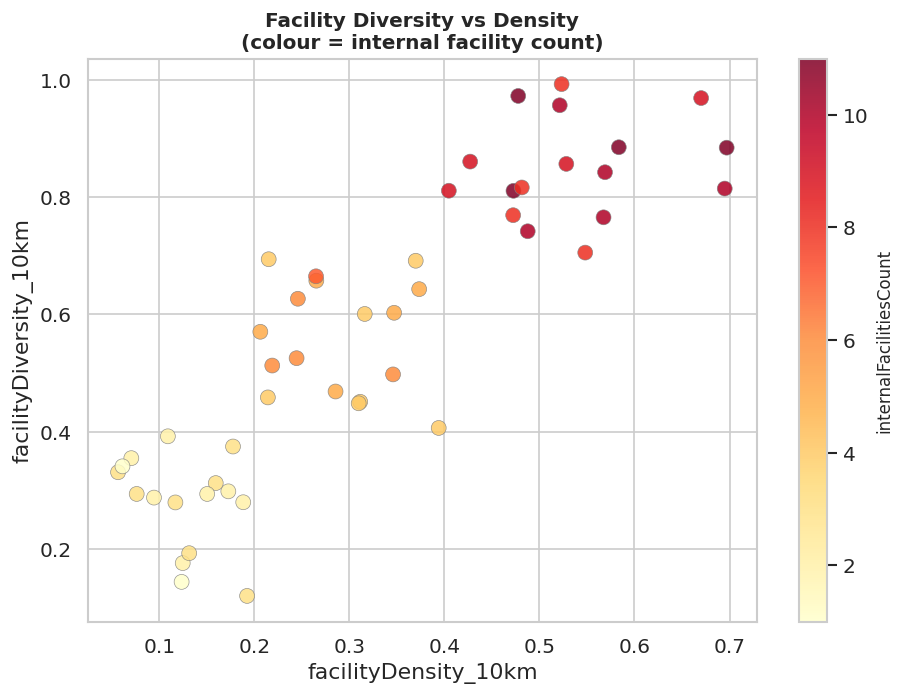

In [16]:
# --- Bivariate Analysis: Facility Diversity vs Density (colour = internal facility count) ---

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    data["facilityDensity_10km"],
    data["facilityDiversity_10km"],
    c=data["internalFacilitiesCount"],
    cmap="YlOrRd",
    s=80,
    alpha=0.85,
    edgecolors="grey",
    linewidth=0.4,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("internalFacilitiesCount", fontsize=10)
ax.set_xlabel("facilityDensity_10km")
ax.set_ylabel("facilityDiversity_10km")
ax.set_title(
    "Facility Diversity vs Density\n(colour = internal facility count)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("eda_diversity_vs_density.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

This single chart carries three dimensions of information simultaneously:

X-axis: facilityDensity_10km | Y-axis: facilityDiversity_10km | Colour: internalFacilitiesCount (yellow = low, dark red = high)

##### Observations:

Top-right region (high density + high diversity):

- Points here are almost exclusively dark red (internal count 8–11)
- This is the Premium cluster region, centers that score well on both external dimensions AND have high internal capacity
- The cluster is tight and well-separated from the bottom-left

##### Bottom-left region (low density + low diversity):

- Points are yellow to light orange (internal count 1–4)
- This is the Basic cluster region, poor external access and limited internal infrastructure
- The grouping is also relatively compact

##### Middle region (moderate density + moderate diversity):

- Points range from orange to light red (internal count 4–8)
- This is the Standard cluster region, adequate but not exceptional on any dimension
- This region is more spread out, which reflects the expected challenge of separating Standard from the other two tiers

##### Critical insight:

The plot shows three visually emergent groups even without running K-Means. This is powerful validation that:

1. The features are appropriate for three-cluster classification
2. A K=3 K-Means model is likely to find clean, meaningful separations
3. The clusters will correspond logically to quality tiers (not arbitrary mathematical groupings)

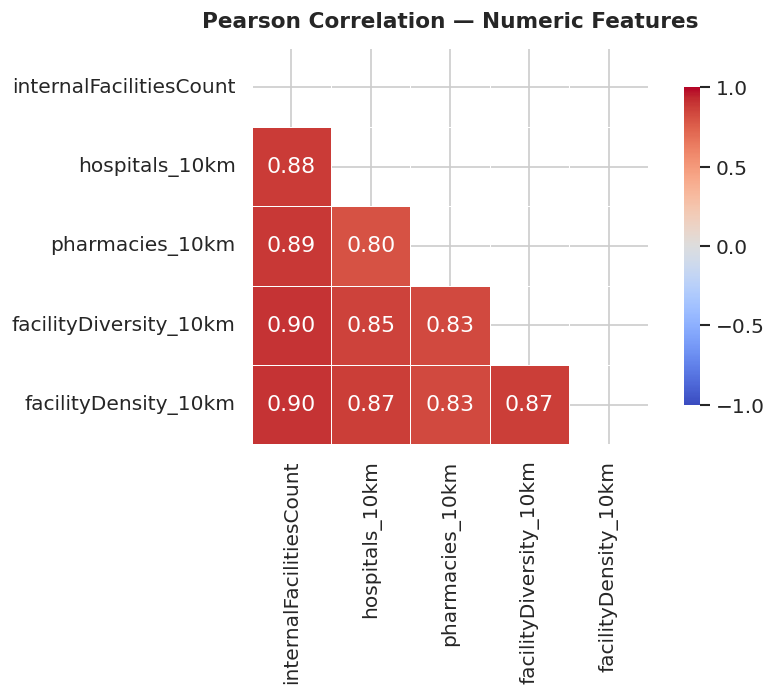

In [17]:
# --- Correlation Heatmap of Numeric Features ---

corr_matrix = data[numeric_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title(
    "Pearson Correlation — Numeric Features",
    fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

##### internalFacilitiesCount ↔ hospitals_10km = 0.88

- Very strong positive correlation
- Centers with more internal labs and workstations tend to be located near more hospitals
- This likely reflects an urban co-location effect, well-funded research centers choose locations near medical infrastructure
- Not redundant, internal count measures the center itself; hospitals measure the surrounding environment. They capture different dimensions of quality

##### internalFacilitiesCount ↔ pharmacies_10km = 0.89

- Near-identical strength to the hospital correlation
- Again reflects co-location: research centers with greater internal capacity tend to be in more developed healthcare zones
- Both hospital and pharmacy count are strong external proxies for center quality

##### internalFacilitiesCount ↔ facilityDiversity_10km = 0.90

- The strongest pairing with internal count
- A center with many internal facilities is almost always in a diverse external healthcare environment
- This confirms the working hypothesis from the scatter plot that internal and external quality move together

##### internalFacilitiesCount ↔ facilityDensity_10km = 0.90

- Equal strength to diversity (both 0.90)
- Higher internal facility count = denser surrounding healthcare environment
- Together, diversity and density provide near-identical information about internal quality

##### facilityDiversity_10km ↔ facilityDensity_10km = 0.87

- The highest inter-feature correlation that does not involve internal count
- These two features are strongly related, an area with dense healthcare will naturally have more varied types of healthcare (diverse)
- Potential redundancy concern: With r = 0.87, one might argue for dropping one of these features. However, they are not identical, a dense but specialised area (e.g., only pharmacies) would score high on density but lower on diversity. Keeping both adds nuance to the clustering

##### hospitals_10km ↔ pharmacies_10km = 0.80

- Strong but not as tight as other pairs
- This makes intuitive sense, an area near many hospitals will usually have pharmacies, but the exact number of each can differ (a hospital district vs a high-street area)

### City Pattern

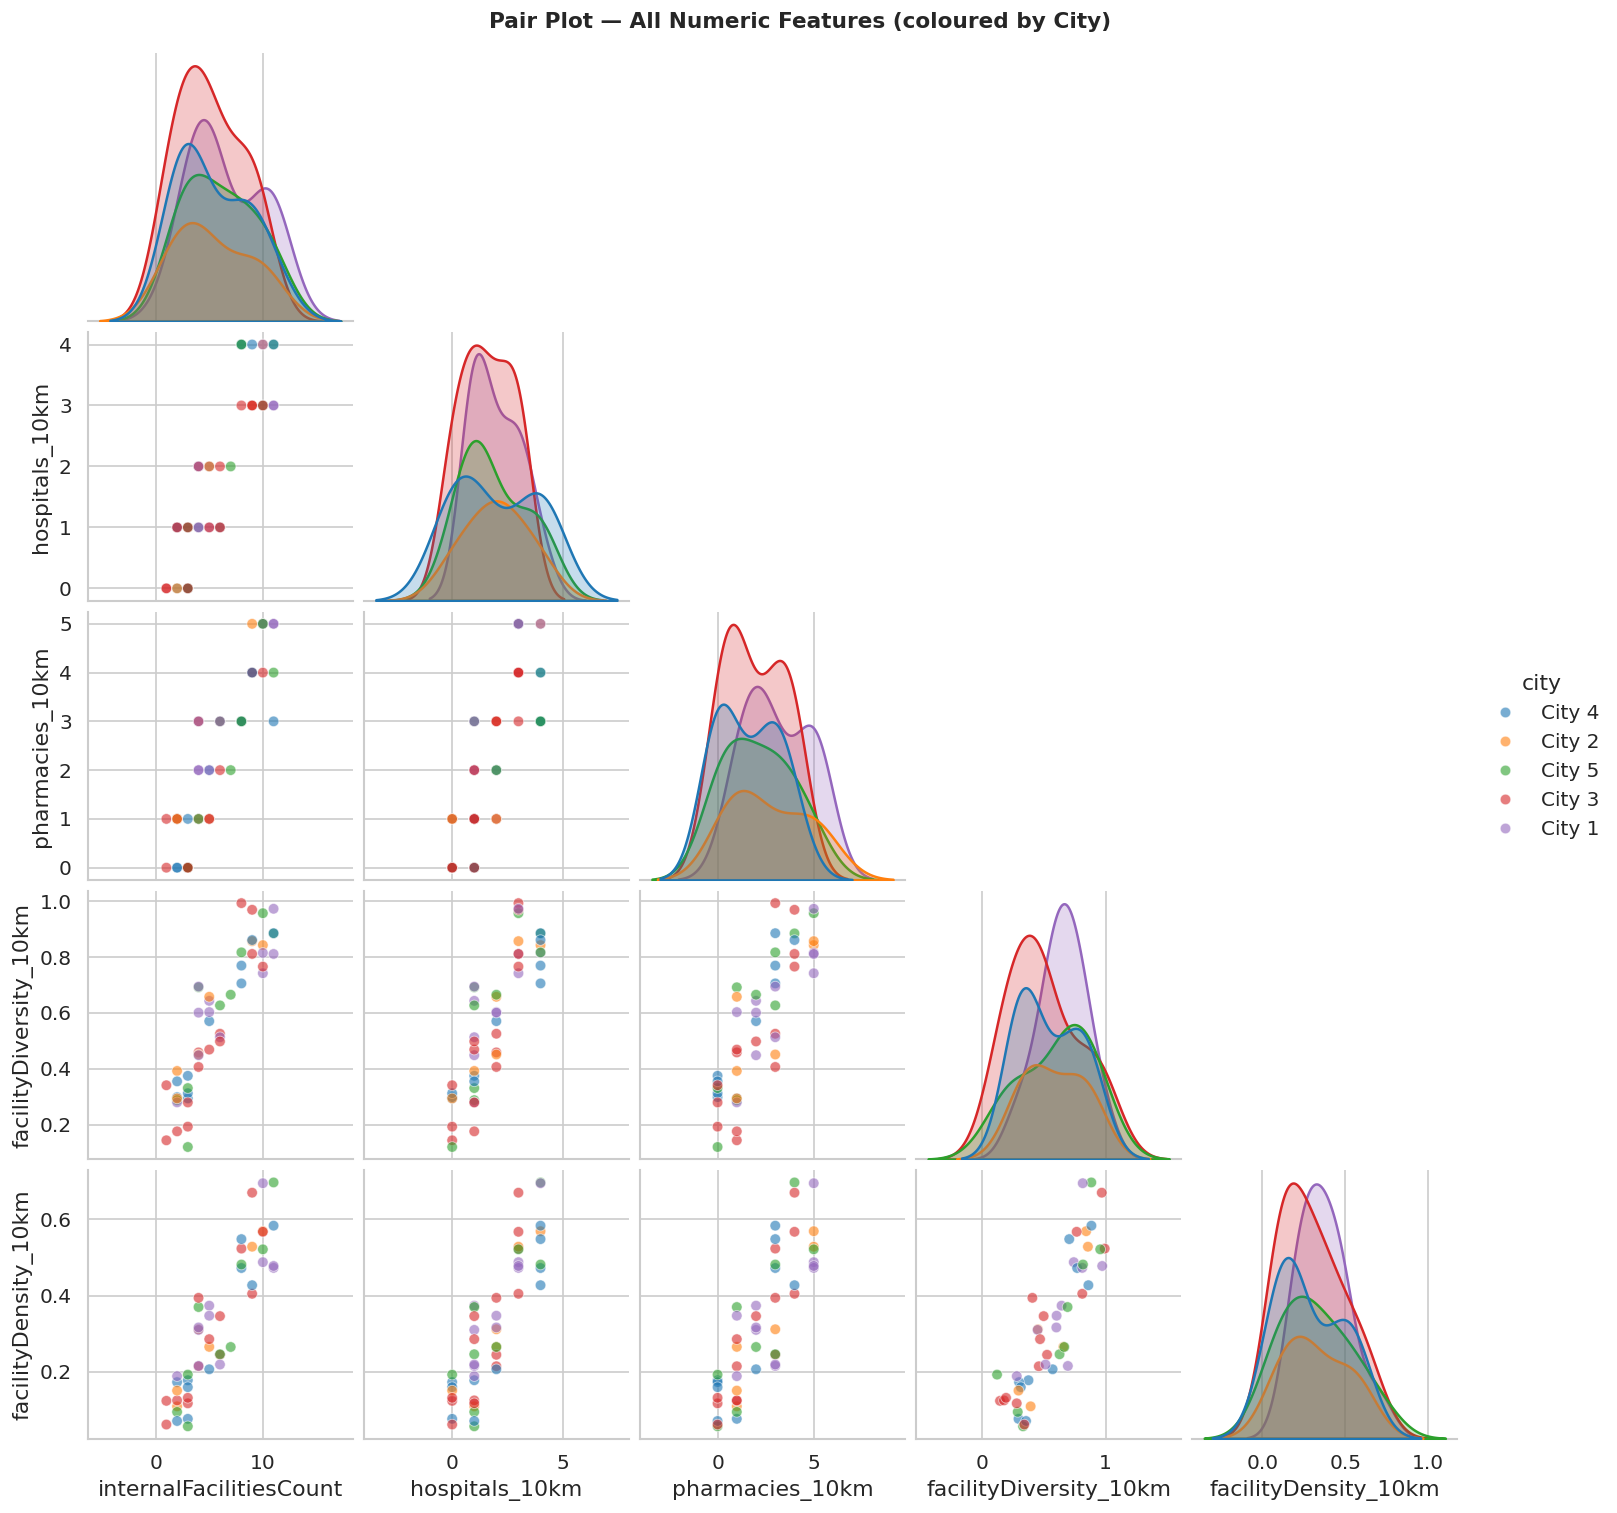

In [18]:
# --- Pair Plot of Numeric Features (coloured by City) ---

pair_data = data[numeric_features + ["city"]].copy()

pair_grid = sns.pairplot(
    pair_data,
    hue="city",
    palette="tab10",
    diag_kind="kde",        # KDE on diagonal instead of histogram for clarity
    plot_kws={"alpha": 0.6, "s": 40},
    diag_kws={"linewidth": 1.5},
    corner=True,            # only lower triangle — avoids redundancy
)
pair_grid.figure.suptitle(
    "Pair Plot — All Numeric Features (coloured by City)",
    y=1.01, fontsize=13, fontweight="bold"
)
pair_grid.savefig("eda_pairplot.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

The pair plot provides the most comprehensive view, it shows every pairwise combination of the five features simultaneously.

Key patterns:

#### Diagonal KDE plots (each feature's distribution per city):

- The KDE curves for each city substantially overlap on every feature
- This confirms that no single city dominates any cluster, all cities contribute centers to all tiers
- City 3 (red) tends to have wider, flatter distributions, reflecting its diversity of center types as the largest group

#### Off-diagonal scatter plots:

- Every scatter plot shows a positive linear pattern, all features move in the same direction together
- The most striking separations are visible in plots involving internalFacilitiesCount vs any other feature, the dots visibly cluster into high (top-right) and low (bottom-left) groups
- facilityDiversity_10km vs facilityDensity_10km (bottom-right off-diagonal) shows the tightest linear relationship between two non-internal-count features, confirming r = 0.87

#### City colour mixing:

- In every scatter panel, all five city colours appear throughout the range, confirming that quality tier is not a function of city
- This means the clustering model will classify based on actual feature values, not geographic location, which is the correct behaviour for a quality classification system

### Outliers Detection

In [19]:
# --- Outlier Detection Summary (IQR method) ---

print("OUTLIER SUMMARY (IQR method, 1.5 × IQR fence)")

outlier_summary = []

for col in numeric_features:
    q1  = data[col].quantile(0.25)
    q3  = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    n_outliers  = ((data[col] < lower_fence) | (data[col] > upper_fence)).sum()
    outlier_summary.append({
        "feature":       col,
        "Q1":            round(q1, 3),
        "Q3":            round(q3, 3),
        "IQR":           round(iqr, 3),
        "lower_fence":   round(lower_fence, 3),
        "upper_fence":   round(upper_fence, 3),
        "n_outliers":    n_outliers,
        "outlier_%":     round(n_outliers / len(data) * 100, 1),
    })

display(pd.DataFrame(outlier_summary))

OUTLIER SUMMARY (IQR method, 1.5 × IQR fence)


,feature,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%
0,internalFacilitiesCount,3.000,8.750,5.750,-5.625,17.375,0,0.0
1,hospitals_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
2,pharmacies_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
3,facilityDiversity_10km,0.344,0.800,0.456,-0.340,1.485,0,0.0
4,facilityDensity_10km,0.174,0.476,0.303,-0.280,0.930,0,0.0


CITY-LEVEL FEATURE SUMMARY


internalFacilitiesCount                hospitals_10km                 \
                          mean    std min max           mean    std min max   
city                                                                          
City 1                   6.545  3.297   2  11          2.000  1.095   1   4   
City 2                   5.333  3.445   2  10          2.000  1.414   0   4   
City 3                   5.071  3.025   1  10          1.571  1.158   0   3   
City 4                   5.400  3.307   2  11          2.000  1.826   0   4   
City 5                   6.000  3.240   2  11          1.889  1.453   0   4   

       pharmacies_10km                facilityDiversity_10km                \
                  mean    std min max                   mean    std    min   
city                                                                         
City 1           3.091  1.640   1   5                  0.647  0.192  0.279   
City 2           2.667  1.966   1   5                  0.582  0.239  0.294   
City 3           1.929  1.542   0   4                  0.502  0.283  0.143   
City 4           1.600  1.578   0   4                  0.542  0.244  0.294   
City 5           2.111  1.764   0   5                  0.598  0.289  0.120   

              facilityDensity_10km                       
          max                 mean    std    min    max  
city                                                     
City 1  0.973                0.373  0.151  0.188  0.695  
City 2  0.857                0.322  0.191  0.109  0.569  
City 3  0.993                0.300  0.191  0.061  0.670  
City 4  0.885                0.289  0.197  0.070  0.583  
City 5  0.957                0.325  0.211  0.057  0.697

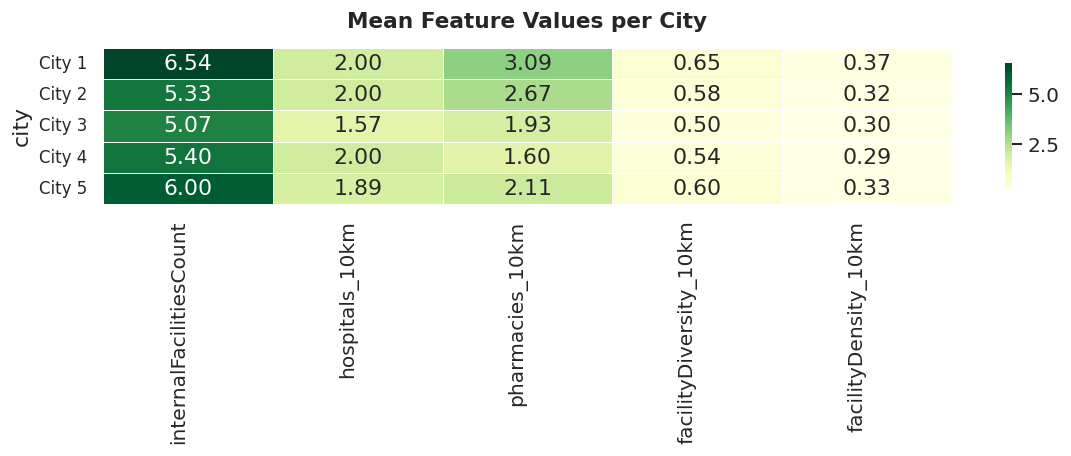

In [20]:
# --- City-Level Summary Statistics for Numeric Features ---

city_summary = (
    data.groupby("city")[numeric_features]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)
print("CITY-LEVEL FEATURE SUMMARY")
display(city_summary)

# Heat-mapped mean values for quick visual scanning
city_means = data.groupby("city")[numeric_features].mean().round(3)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    city_means,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title(
    "Mean Feature Values per City",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

plt.subplots_adjust(left=0.25)
plt.tight_layout()
plt.savefig("eda_city_mean_heatmap.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATION

- City 1 is the highest-performing city across all five features: It has the highest internal facility count (6.54), most pharmacies (3.09), highest diversity (0.65), and highest density (0.37). This means City 1 centers are most likely to fall in the Premium cluster

- City 3 is the lowest performer overall: Despite having the most centers (14), it has the lowest internal count (5.07), fewest hospitals (1.57), fewest pharmacies (1.93), and lowest diversity (0.50). Its centers are most likely to fall in the Basic cluster

- Hospital access is remarkably uniform: All cities average between 1.57 and 2.00 hospitals, meaning this feature alone is not a strong city-level differentiator

- Pharmacy access shows the most city-level variation: City 1 (3.09) vs City 4 (1.60) is nearly double, making pharmacies a stronger geographic signal than hospitals

- Density and diversity move together: Across all cities, the ranking order is identical (City 1 > City 2/5 > City 3/4), confirming their correlation before even looking at the heatmap

- No single city has all low values: Even City 3's density (0.30) is moderate, suggesting no city is entirely in the Basic tier; quality is spread across the geography

#### EDA SUMMARY

- Dataset is clean: Zero missing values, all types correct, all range valid. No preprocessing needed beyond scaling
- 50 centers across 5 cities
- All 5 features are positively correlated (0.80 t0 0.90)
- Three natural groupings exist based on diversity vs density scatter plot and histogram bimodality
- City 1 has the highest quality on average: Expected to contribute more Premium centers
- City 3 has the lowest average quality: Expected to contribute more basic centers
- City is not a quality determinant: Based on the boxplots and pair plot, so it should not be a clustering feature
- Internal count is the anchor feature: r=0.90 with both diversity and density, it should the primary driver of premium vs basic separation
- Density and diversity have identical correlations
- Some right skew in density: Standard scalar will normalise this before clustering



## Feature Selection